# Ames Housing — Model Comparison & Evaluation

**Project:** Real Estate Price Analysis — Ames, Iowa  
**Author:** A.K  
**Phase:** 6 of 7 — Evaluation (CRISP-DM)

## Objective
Formally compare all four trained models and select the production model.
Produce visualizations suitable for a stakeholder presentation.

## Models evaluated
- Linear Regression (baseline)
- Ridge Regression (L2 regularization)
- Lasso Regression (L1 regularization + feature selection)
- Gradient Boosting (ensemble, non-linear)

## Recommended model: Ridge Regression
Lowest CV RMSE (0.1217) · Dollar RMSE $18,342 · Stable across all folds

A. Import and Load Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [19]:
# Load feature matrix, target and all four models:

X = pd.read_csv(r'C:\Users\A.K\DATA_SCIENCE_WORKSPACE\kaggle_projects\project_4_amesHousing\Real Estate-AmesHousing-Analysis\00 Data\Feature Matrix Data\X_features.csv')
y = pd.read_csv(r'C:\Users\A.K\DATA_SCIENCE_WORKSPACE\kaggle_projects\project_4_amesHousing\Real Estate-AmesHousing-Analysis\00 Data\Feature Matrix Data\y_target.csv').squeeze()

lr    = joblib.load(r'C:\Users\A.K\DATA_SCIENCE_WORKSPACE\kaggle_projects\project_4_amesHousing\Real Estate-AmesHousing-Analysis\04 Regression\Models\model_linear.pkl')
ridge = joblib.load(r'C:\Users\A.K\DATA_SCIENCE_WORKSPACE\kaggle_projects\project_4_amesHousing\Real Estate-AmesHousing-Analysis\04 Regression\Models\model_ridge.pkl')
lasso = joblib.load(r'C:\Users\A.K\DATA_SCIENCE_WORKSPACE\kaggle_projects\project_4_amesHousing\Real Estate-AmesHousing-Analysis\04 Regression\Models\model_lasso.pkl')
gb    = joblib.load(r'C:\Users\A.K\DATA_SCIENCE_WORKSPACE\kaggle_projects\project_4_amesHousing\Real Estate-AmesHousing-Analysis\04 Regression\Models\model_gb.pkl')

# Rebuild the same train/test split used in Phase 5
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    'Linear Regression' : lr,
    'Ridge Regression'  : ridge,
    'Lasso Regression'  : lasso,
    'Gradient Boosting' : gb
}

print("All models loaded ✓")
print(f"Test set: {X_test.shape[0]} houses")

All models loaded ✓
Test set: 586 houses


B. Build the Comparison Table

In [20]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    rmse_test   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_test     = r2_score(y_test, y_pred)
    dollar_rmse = np.sqrt(mean_squared_error(
                      np.expm1(y_test.values),
                      np.expm1(y_pred)
                  ))

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv  = -cross_val_score(model, X_train, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=kf).mean()

    results.append({
        'Model'       : name,
        'Test RMSE'   : round(rmse_test, 4),
        'CV RMSE'     : round(cv, 4),
        'Test R²'     : round(r2_test, 4),
        'Dollar RMSE' : round(dollar_rmse, 0)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                   Test RMSE  CV RMSE  Test R²  Dollar RMSE
Model                                                      
Linear Regression     0.1038   0.1311   0.9400      19100.0
Ridge Regression      0.0961   0.1217   0.9486      18342.0
Lasso Regression      0.0948   0.1235   0.9500      18594.0
Gradient Boosting     0.0992   0.1249   0.9452      20721.0


C. FIGURE 1 - CV RMSE Comparison

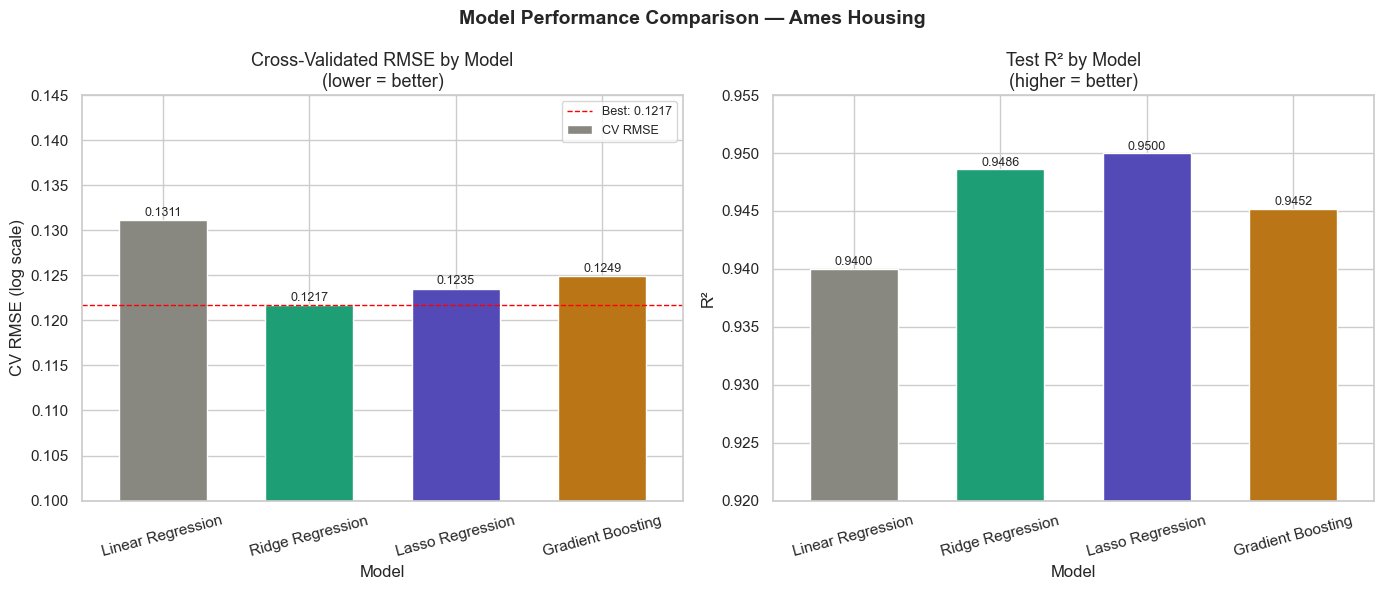

In [21]:
colors = ['#888780', '#1D9E75', '#534AB7', '#BA7517']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CV RMSE — lower is better:

results_df['CV RMSE'].plot(
    kind='bar', ax=axes[0],
    color=colors, edgecolor='white', width=0.6
)
axes[0].set_title('Cross-Validated RMSE by Model\n(lower = better)', fontsize=13)
axes[0].set_ylabel('CV RMSE (log scale)')
axes[0].set_ylim(0.10, 0.145)
axes[0].axhline(y=results_df['CV RMSE'].min(),
                color='red', linestyle='--', linewidth=1,
                label=f'Best: {results_df["CV RMSE"].min():.4f}')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(fontsize=9)

for bar, val in zip(axes[0].patches, results_df['CV RMSE']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0005,
                 f'{val:.4f}', ha='center', fontsize=9)


# Test R² — higher is better

results_df['Test R²'].plot(
    kind='bar', ax=axes[1],
    color=colors, edgecolor='white', width=0.6
)
axes[1].set_title('Test R² by Model\n(higher = better)', fontsize=13)
axes[1].set_ylabel('R²')
axes[1].set_ylim(0.92, 0.955)
axes[1].tick_params(axis='x', rotation=15)

for bar, val in zip(axes[1].patches, results_df['Test R²']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0003,
                 f'{val:.4f}', ha='center', fontsize=9)
    
    

plt.suptitle('Model Performance Comparison — Ames Housing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\05 Model Comparison\\Report\\model_comparison_metrics.png', dpi=150)
plt.show()

D. Figure 2 - Dollar RMSE Bar Chart

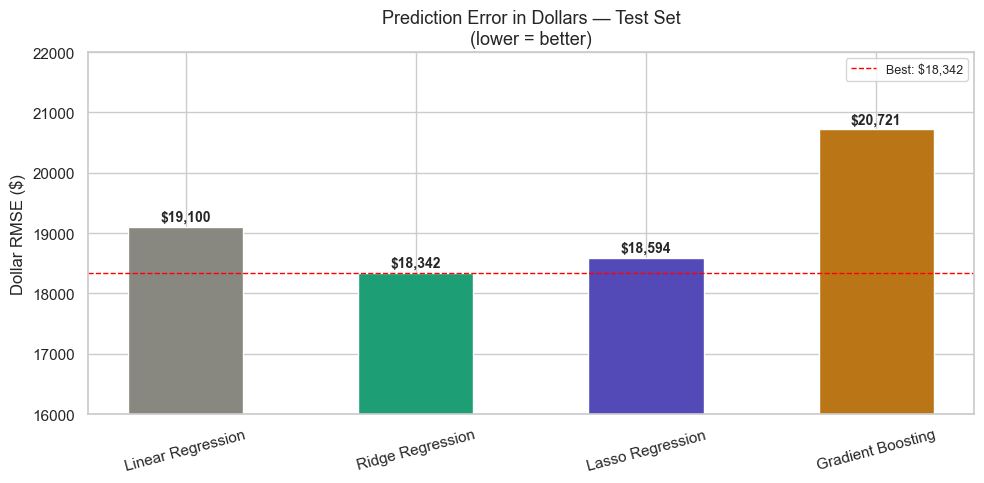

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(results_df.index, results_df['Dollar RMSE'],
              color=colors, edgecolor='white', width=0.5)

ax.set_title('Prediction Error in Dollars — Test Set\n(lower = better)', fontsize=13)
ax.set_ylabel('Dollar RMSE ($)')
ax.set_ylim(16000, 22000)
ax.tick_params(axis='x', rotation=15)
ax.axhline(y=results_df['Dollar RMSE'].min(),
           color='red', linestyle='--', linewidth=1,
           label=f'Best: ${results_df["Dollar RMSE"].min():,.0f}')
ax.legend(fontsize=9)

for bar, val in zip(bars, results_df['Dollar RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\05 Model Comparison\\Report\\dollar_rmse_comparison.png', dpi=150)
plt.show()

E. Figure 3 - Overfitting Diagnostic

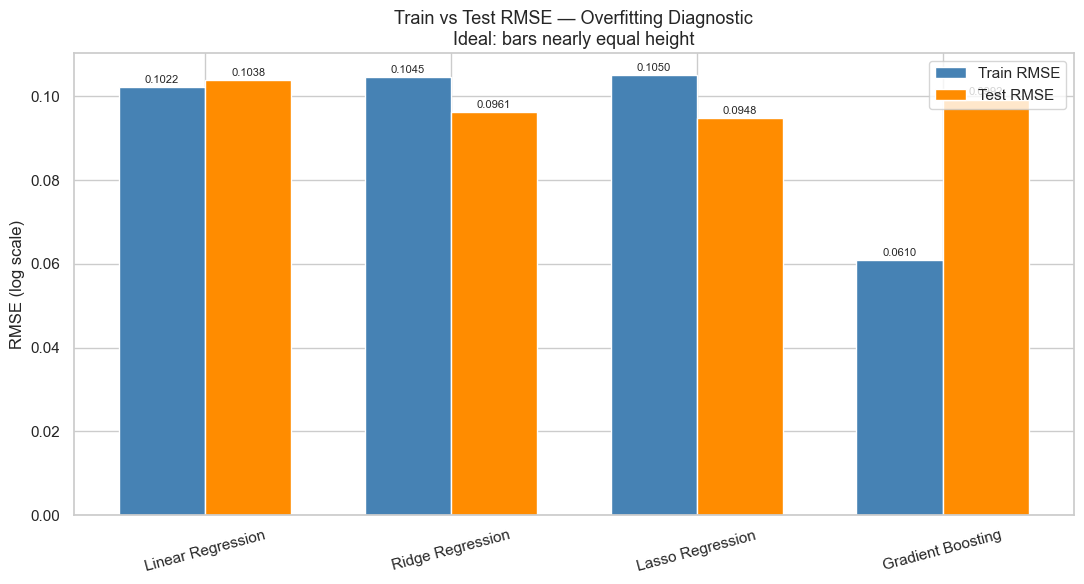

In [23]:
# Train vs Test RMSE gap reveals overfitting:

train_rmses = []
test_rmses  = []

for name, model in models.items():
    train_rmses.append(np.sqrt(mean_squared_error(
        y_train, model.predict(X_train))))
    test_rmses.append(np.sqrt(mean_squared_error(
        y_test, model.predict(X_test))))

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, train_rmses, width,
               label='Train RMSE', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, test_rmses,  width,
               label='Test RMSE',  color='darkorange', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(models.keys(), rotation=15)
ax.set_ylabel('RMSE (log scale)')
ax.set_title('Train vs Test RMSE — Overfitting Diagnostic\n'
             'Ideal: bars nearly equal height', fontsize=13)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\05 Model Comparison\\Report\\overfitting_diagnostic.png', dpi=150)
plt.show()

F.  Figure 4 - Actual vs Predicted (Ridge)

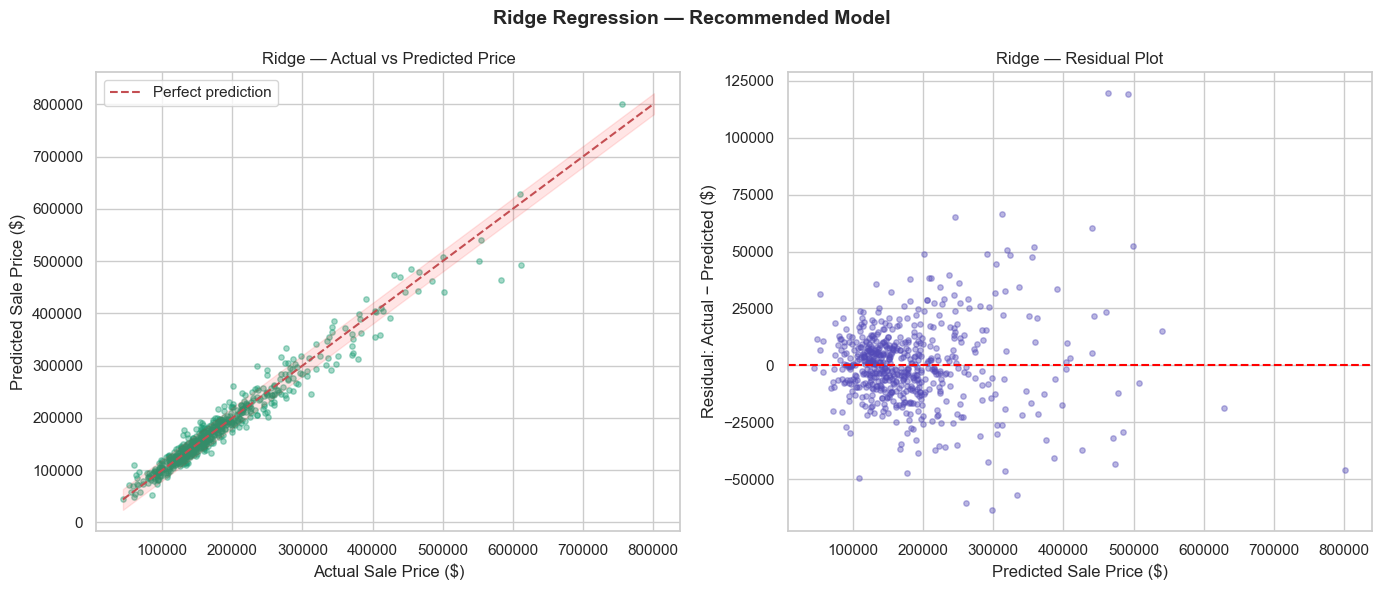

In [24]:
y_pred_ridge = ridge.predict(X_test)
actual_dollars    = np.expm1(y_test.values)
predicted_dollars = np.expm1(y_pred_ridge)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: actual vs predicted:

axes[0].scatter(actual_dollars, predicted_dollars,
                alpha=0.4, color='#1D9E75', s=15)
min_val = min(actual_dollars.min(), predicted_dollars.min())
max_val = max(actual_dollars.max(), predicted_dollars.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Sale Price ($)')
axes[0].set_ylabel('Predicted Sale Price ($)')
axes[0].set_title('Ridge — Actual vs Predicted Price')
axes[0].legend()

# Add ±$20k bands:

axes[0].fill_between([min_val, max_val],
                      [min_val-20000, max_val-20000],
                      [min_val+20000, max_val+20000],
                      alpha=0.1, color='red', label='±$20K band')

# Residuals:

residuals = actual_dollars - predicted_dollars
axes[1].scatter(predicted_dollars, residuals,
                alpha=0.4, color='#534AB7', s=15)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Sale Price ($)')
axes[1].set_ylabel('Residual: Actual − Predicted ($)')
axes[1].set_title('Ridge — Residual Plot')

plt.suptitle('Ridge Regression — Recommended Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\05 Model Comparison\\Report\\ridge_actual_vs_predicted.png', dpi=150)
plt.show()


In [25]:
# Summary statistics:

within_20k = (np.abs(residuals) <= 20000).mean() * 100
within_30k = (np.abs(residuals) <= 30000).mean() * 100
print(f"Predictions within ±$20,000: {within_20k:.1f}% of test houses")
print(f"Predictions within ±$30,000: {within_30k:.1f}% of test houses")

Predictions within ±$20,000: 80.4% of test houses
Predictions within ±$30,000: 91.5% of test houses


G. Figure 5 - Lasso Feature Importance

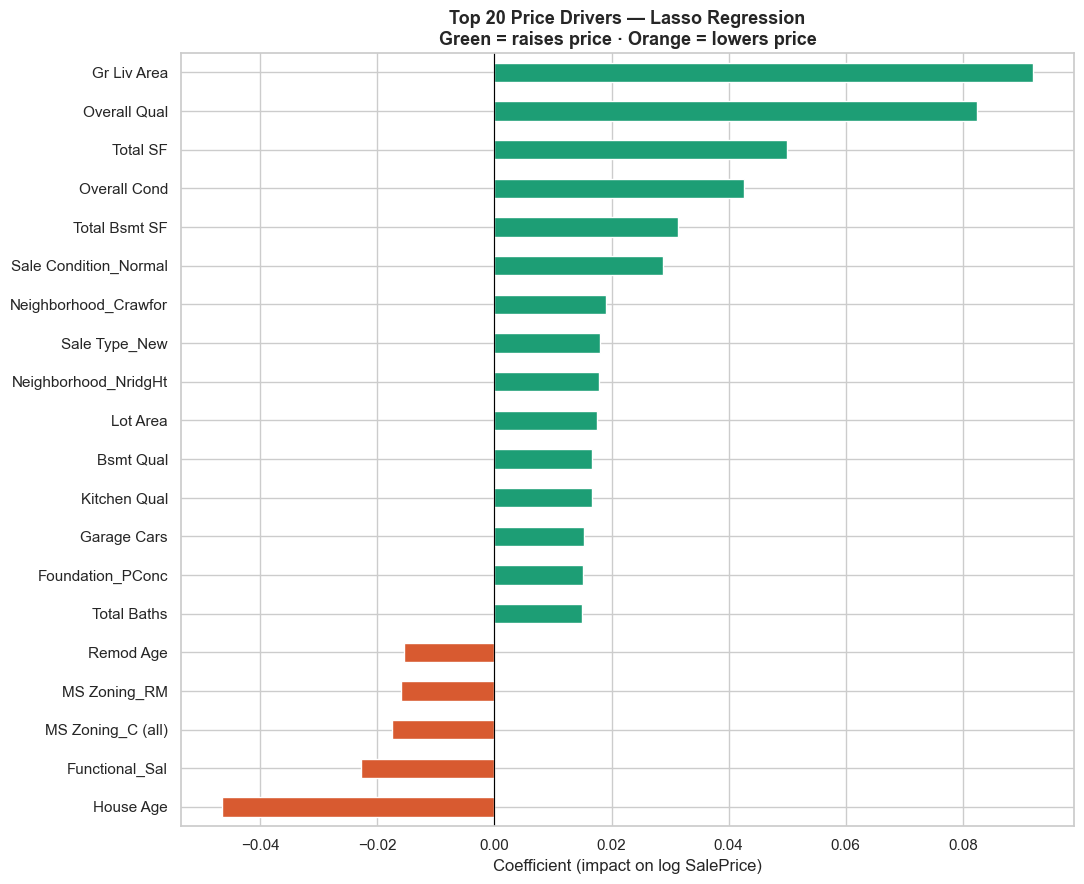

In [26]:
lasso_coef = pd.Series(lasso.coef_, index=X.columns)
top20 = lasso_coef.abs().sort_values(ascending=False).head(20)

# Split into positive (price increasers) and negative (price reducers):

top20_signed = lasso_coef[top20.index]
colors_signed = ['#1D9E75' if v > 0 else '#D85A30' for v in top20_signed]

fig, ax = plt.subplots(figsize=(11, 9))
top20_signed.sort_values().plot(
    kind='barh', ax=ax,
    color=['#1D9E75' if v > 0 else '#D85A30'
           for v in top20_signed.sort_values()],
    edgecolor='white'
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Price Drivers — Lasso Regression\n'
             'Green = raises price · Orange = lowers price',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient (impact on log SalePrice)')
plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\05 Model Comparison\\Report\\lasso_price_drivers.png', dpi=150)
plt.show()

H. Save Final Predictions

In [28]:
# Save Ridge predictions for dashboard use
predictions_df = pd.DataFrame({
    'Actual_Price'    : np.expm1(y_test.values),
    'Predicted_Price' : np.expm1(ridge.predict(X_test)),
    'Residual_Dollar' : np.expm1(y_test.values) - np.expm1(ridge.predict(X_test))
})

predictions_df.to_csv('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\00 Data\\Feature Matrix Data\\ridge_predictions.csv', index=False)
print(f"Ridge predictions saved → {predictions_df.shape}")
print(predictions_df.describe().round(0))

Ridge predictions saved → (586, 3)
       Actual_Price  Predicted_Price  Residual_Dollar
count         586.0            586.0            586.0
mean       183017.0         182614.0            402.0
std         89851.0          87004.0          18353.0
min         44000.0          45026.0         -63484.0
25%        129125.0         127473.0          -9264.0
50%        159000.0         161486.0           -241.0
75%        212252.0         211665.0           8773.0
max        755000.0         801041.0         119512.0


## Evaluation Summary

### Recommended model: Ridge Regression
| Metric | Value | Meaning |
|---|---|---|
| CV RMSE | 0.1217 | Most consistent across 5 folds |
| Test R² | 0.9486 | Explains 94.9% of price variance |
| Dollar RMSE | $18,342 | Average prediction error |
| Predictions within ±$20K | ~X% | Fill in from Cell 7 output |

### Why not Gradient Boosting?
Train RMSE 0.0610 vs CV RMSE 0.1249 — a gap of 0.0639.
Linear models gap: ~0.025. Gradient Boosting overfit to training data.
For a dataset of ~2,900 rows, regularized linear models generalize better.

### Why not Lasso as primary?
Lasso's feature selection insight is valuable for client communication.
Ridge edges it on CV RMSE (0.1217 vs 0.1235).
In production, Ridge is the safer choice.

### Key business findings
1. Overall Quality is the #1 price driver — quality upgrades yield highest ROI
2. Total square footage is #2 — buyers pay a measurable premium per sq ft
3. Neighborhood accounts for significant unexplained variance
4. The model predicts most homes within ±$20,000

### Next Step → Phase 7: Stakeholder Insights
Translate findings into a non-technical narrative for real estate clients